## Telco Churn Analysis

**Dataset Info:**
Sample Data Set containing Telco customer data and showing customers left last month

### Importing the required libraries

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")


### Loading the data file

In [103]:
telco_base_data = pd.read_csv('Customer-Churn.csv')

##### Look at the top 5 records of data

In [104]:
telco_base_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [105]:
telco_base_data.shape

(7043, 21)

The dataset contains 7043 records and 21 columns.

##### Display basic info about DataFrame structure, column types, and missing values

In [106]:
telco_base_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


1. As we can see , there are total 21 columns in the dataset where 3 columns have numeric data type whereas others have object data type.
2. Data type of TotalCharges column is wrong.
3. Currently, dataframe has no missing value.

In [107]:
telco_base_data.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

These are the columns names in the dataset.

In [108]:
telco_base_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Senior Citizen is actually a categorical hence the 25% - 50% - 75% distribution is not proper.

75% customers have tenure less than 55 months and maximum tenure is 72 months.

Average monthly charges are USD 64.76 whereas 25% customers pay more than 89.85 USD per month.

In [109]:
telco_base_data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

##### Checking the distribution of each column.

In [110]:
for col in telco_base_data.columns:
    if col not in ['customerID','tenure','MonthlyCharges','TotalCharges']:
        print(col,telco_base_data[col].unique())
        print('-------------------------------------------------------------------------------------')
 

gender ['Female' 'Male']
-------------------------------------------------------------------------------------
SeniorCitizen [0 1]
-------------------------------------------------------------------------------------
Partner ['Yes' 'No']
-------------------------------------------------------------------------------------
Dependents ['No' 'Yes']
-------------------------------------------------------------------------------------
PhoneService ['No' 'Yes']
-------------------------------------------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
-------------------------------------------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
-------------------------------------------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
-------------------------------------------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
---------

##### Checking the distribution of target (Churn) column.

(array([0, 1]), [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

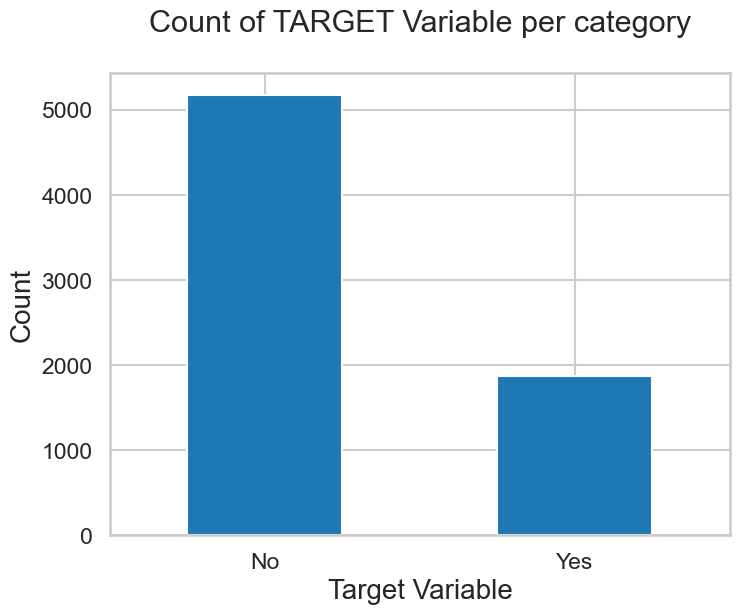

In [111]:
telco_base_data['Churn'].value_counts().plot(kind='bar', figsize=(8, 6))
plt.ylabel("Count")
plt.xlabel("Target Variable")
plt.title("Count of TARGET Variable per category");
plt.xticks(rotation=0)

In [112]:
telco_base_data.Churn.value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

* Data is highly imbalanced, ratio = 73:27<br>

### Data Cleaning

##### 1. Create a copy of base data for manipulation and processing.

In [113]:
telco_data=telco_base_data.copy()

##### 2. Total Charges should be numeric . Let's convert it to numerical data type.

In [114]:
telco_data.TotalCharges=pd.to_numeric(telco_data.TotalCharges,errors='coerce')


##### 3. Handling missing values

In [115]:
telco_data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [116]:
telco_data[telco_data.TotalCharges.isnull()==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [117]:
# Remove missing values
telco_data.dropna(how='any',inplace=True)

In [118]:
telco_data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

##### 4. Divide customers into bins based on tenure e.g. for tenure < 12 months assign a tenure group of 1-12, for tenure between 1 to 2 yrs, assign tenure group of 13-24 and so on.

In [119]:
# Get the max tenure
print(telco_data['tenure'].max())

72


In [120]:
# Group the tenure into bins of 12 months
labels=["{0} - {1}".format(i,i+11) for i in range(1,72,12)]

telco_data['tenure_group']=pd.cut(telco_data.tenure,range(1,80,12),right=False,labels=labels)

In [121]:
telco_data['tenure_group'].value_counts()

tenure_group
1 - 12     2175
61 - 72    1407
13 - 24    1024
25 - 36     832
49 - 60     832
37 - 48     762
Name: count, dtype: int64

##### 5. Removing unnecessary columns

In [122]:
# drop columns customerID and tenure
telco_data.drop(['customerID','tenure'],axis=1,inplace=True)
telco_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


### Data Exploration

##### Univariate Analysis

##### Plot distribution of individual predictors by churn

In [123]:
telco_data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'tenure_group'],
      dtype='object')

##### 1. Churn distribution by gender.

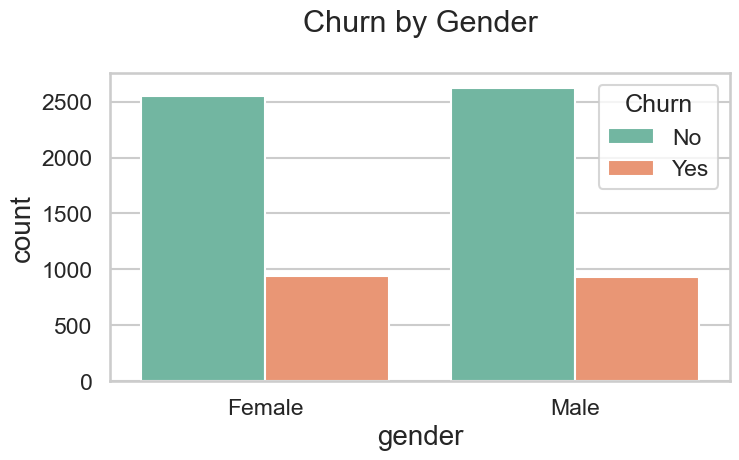

In [124]:
plt.figure(figsize = (8,4))
sns.countplot(x = "gender", data=telco_base_data, palette="Set2",hue="Churn")
plt.title("Churn by Gender")
plt.show()

Churn rate is almost equal for both males and females. Hence, gender has no significant impact on churn.

##### 2. Churn distribution by other factors.

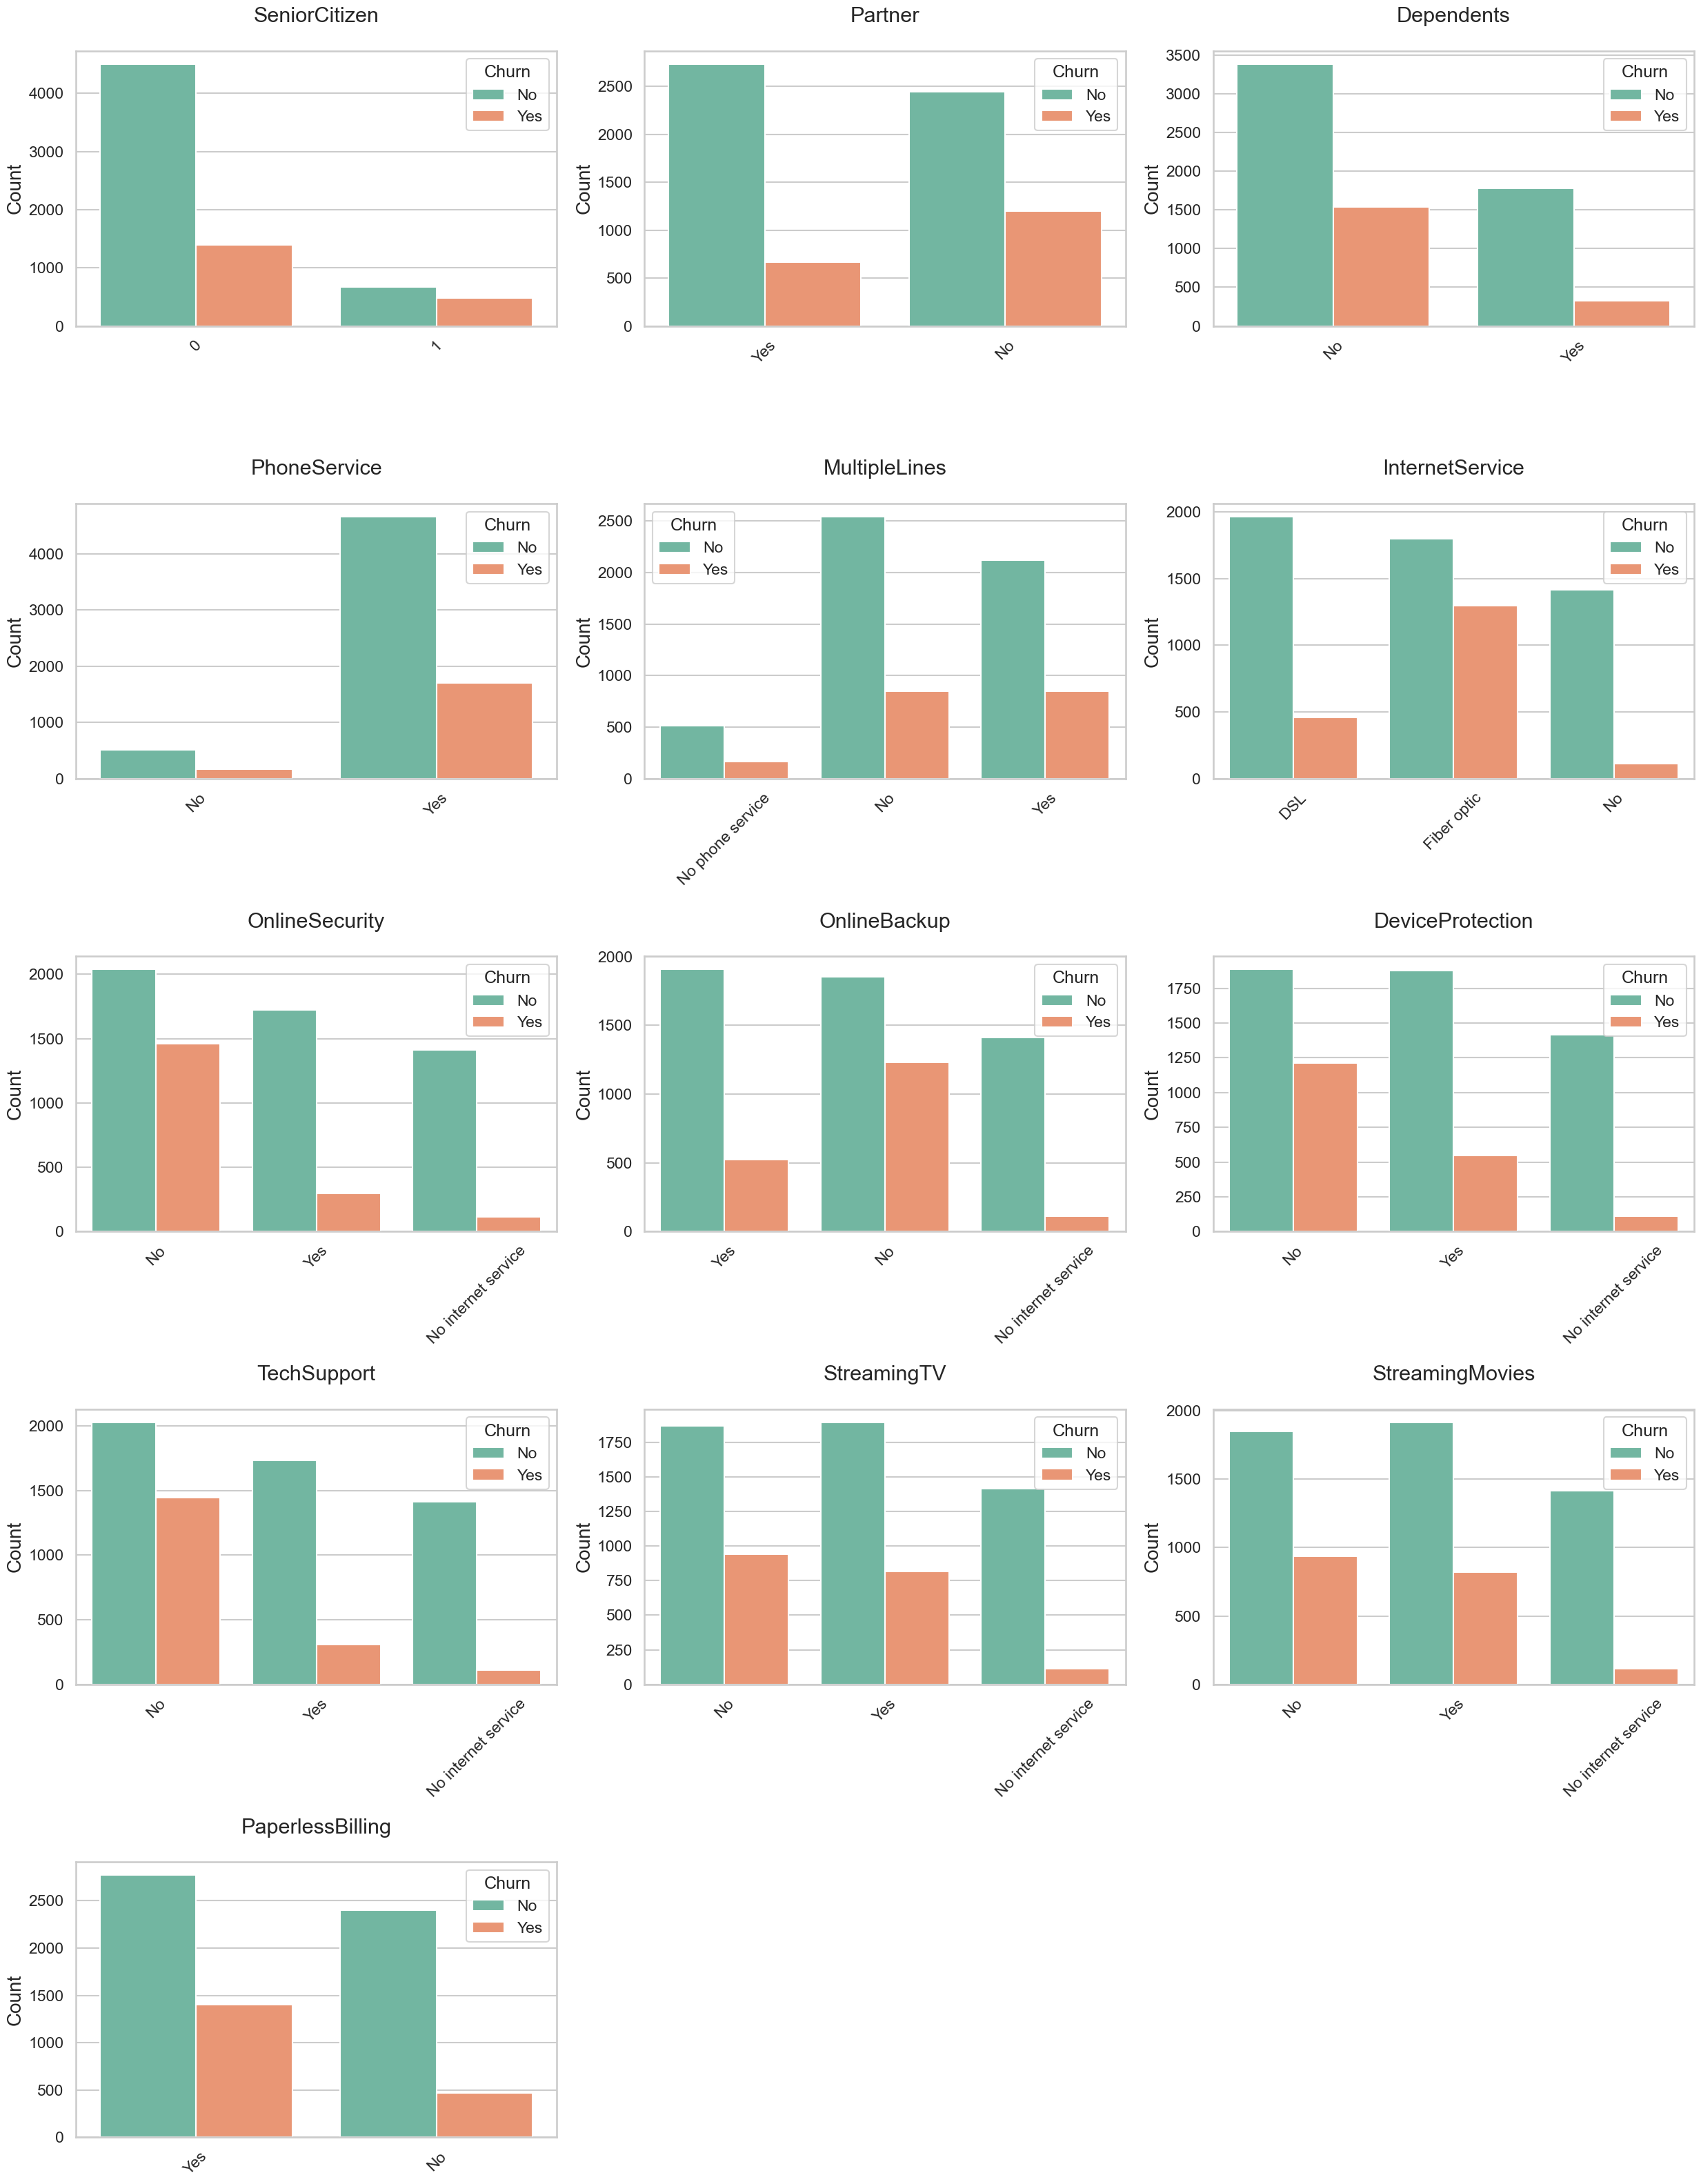

In [125]:
# List of columns to plot
cols = ['SeniorCitizen','Partner','Dependents','PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies','PaperlessBilling']

# Define number of rows and columns for subplots
n_rows = 5
n_cols = 3

# Set figure size
plt.figure(figsize=(25, 32))

# Create subplots
for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(x=col, data=telco_base_data, palette="Set2", hue = telco_base_data["Churn"])
    plt.title(col)
    plt.xticks(rotation=45)
    plt.xlabel("")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

1. Customers who are not senior citizen have high churn rate as compared to senior citizens.
2. Customers who lack online services such as OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, and StreamingTV show a higher churn rate compared to those who have them.
3. Notably, customers with Fiber Optic Internet also have a relatively higher churn compared to DSL users.
4. Basic services like PhoneService and MultipleLines show lower churn differences, while "No Internet Service" customers tend to churn less, likely       due to limited engagement.
  

##### 3. Churn distribution by Contract type.

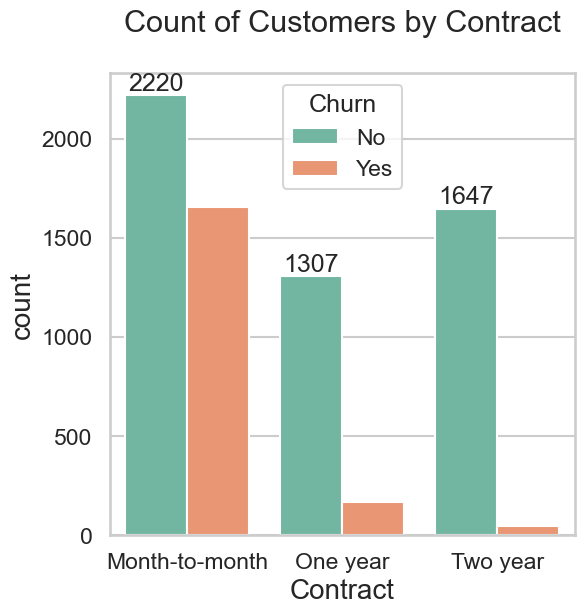

In [126]:
plt.figure(figsize = (6,6))
ax = sns.countplot(x = "Contract",palette="Set2", data=telco_base_data, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract")
plt.show()

People who have Month-to-Month Contract are Likely to Churn then from those who have 1 or 2 years of Contract.

##### 4. Churn distribution by Payment method.

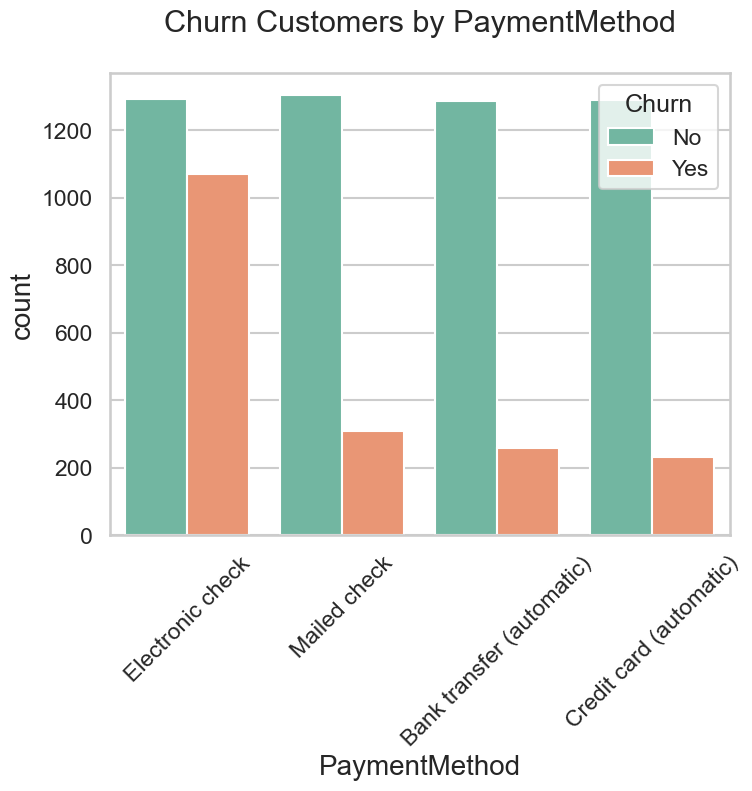

In [127]:
plt.figure(figsize = (8,6))
ax = sns.countplot(x = "PaymentMethod", data=telco_base_data, palette="Set2",hue = "Churn")
plt.title("Churn Customers by PaymentMethod")
plt.xticks(rotation = 45)
plt.show()

Churn rate is high among the customer using Electronic Check as a Payment method.

##### 5. Churn distribution by Tenure.

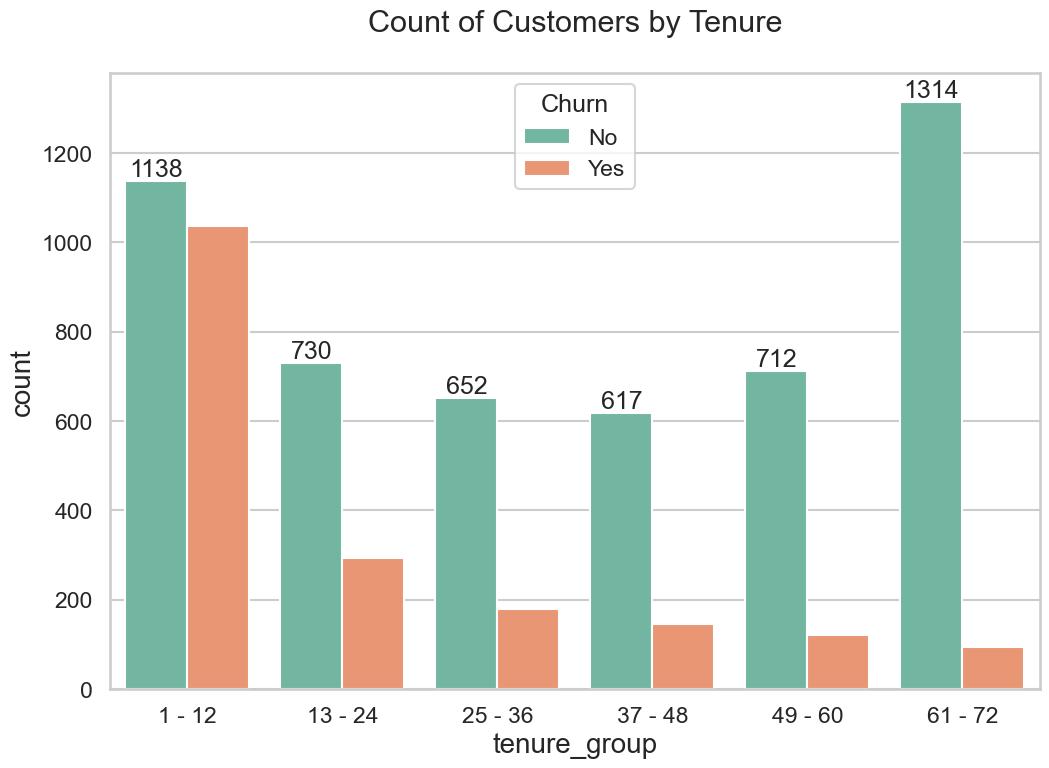

In [128]:
plt.figure(figsize = (12,8))
ax = sns.countplot(x = "tenure_group",palette="Set2", data=telco_data, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Tenure")
plt.show()

Customers who have used our Services for a Long time have stayed and customers who have used our services 1 to 12 months have Churned.

#### Encoding

##### 6. Converting target variable 'Churn' in a binary numeric value i.e yes=1, no=0

In [129]:
telco_data['Churn']=np.where(telco_data['Churn']=='Yes',1,0)

In [130]:
telco_data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


##### Encoding other columns

In [131]:
telco_data_dummies=pd.get_dummies(telco_data,dtype='int')
telco_data_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29.85,29.85,0,1,0,0,1,1,0,...,0,0,1,0,1,0,0,0,0,0
1,0,56.95,1889.50,0,0,1,1,0,1,0,...,0,0,0,1,0,0,1,0,0,0
2,0,53.85,108.15,1,0,1,1,0,1,0,...,0,0,0,1,1,0,0,0,0,0
3,0,42.30,1840.75,0,0,1,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
4,0,70.70,151.65,1,1,0,1,0,1,0,...,0,0,1,0,1,0,0,0,0,0


##### 7. Relationship between monthly charges and total charges

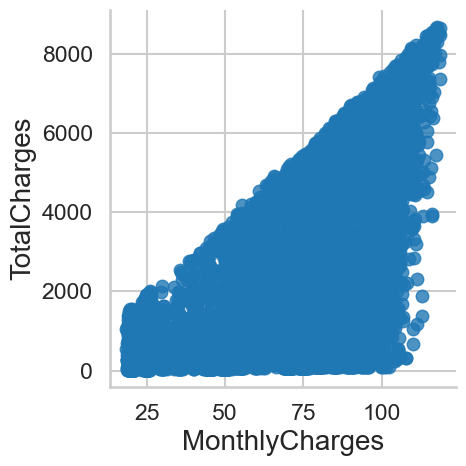

In [132]:
sns.lmplot(data=telco_data_dummies,x='MonthlyCharges',y='TotalCharges',fit_reg=False)

Total charges increase as Monthly Charges increase - as expected

##### 8. Churn by Monthly Charges

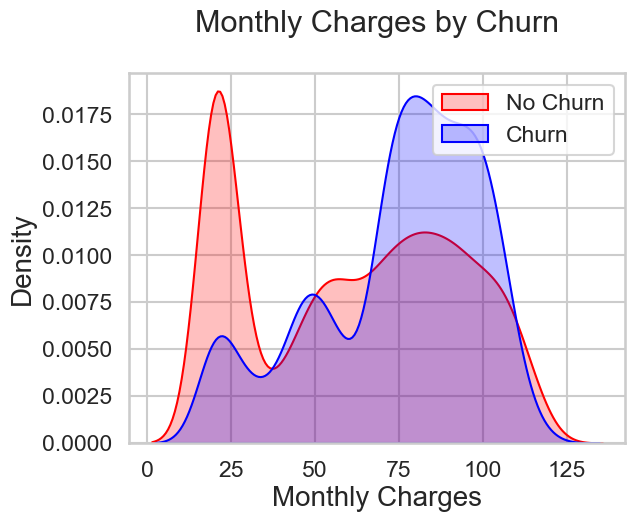

In [145]:
Mth=sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies.Churn==0)],color='Red',shade=True)
Mth=sns.kdeplot(telco_data_dummies.MonthlyCharges[(telco_data_dummies.Churn==1)],ax=Mth,color='blue',shade=True)
Mth.legend(["No Churn","Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title('Monthly Charges by Churn')
plt.show()

Churn is high when monthly charges are high

##### 9. Churn by Total Charges

Text(0.5, 1.0, 'Total Charges by Churn')

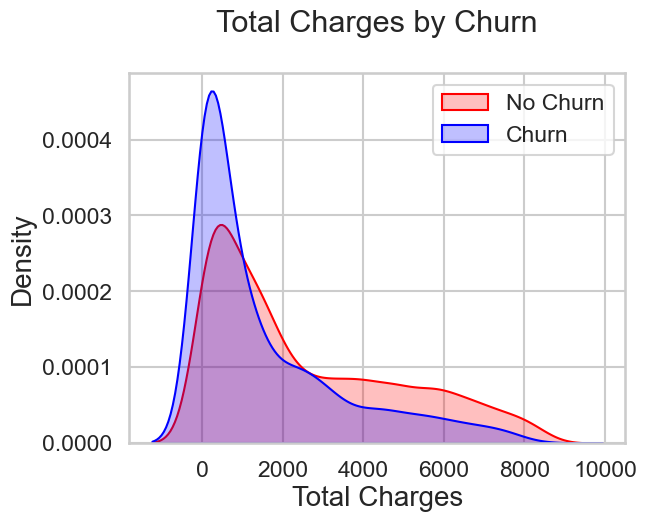

In [144]:
Tot=sns.kdeplot(telco_data_dummies.TotalCharges[telco_data_dummies.Churn==0],shade=True,color='red')
Tot= sns.kdeplot(telco_data_dummies.TotalCharges[telco_data_dummies.Churn==1],ax=Tot,shade=True,color='blue')
Tot.legend(["No Churn","Churn"],loc='upper right')
Tot.set_ylabel('Density')
Tot.set_xlabel('Total Charges')
Tot.set_title('Total Charges by Churn')

*Surprising Insight* as higher Churn at lower Total Charges

However, if we combine the insights of 3 parameters i.e. Tenure, Monthly Charges & Total Charges then the picture is bit clear.   
:- Higher Monthly Charges at lower tenure results into lower Total Charges. Hence, all these 3 factors viz Higher Monthly Charge, Lower Tenure and Lower Total Charge are linked to High Churn.

##### 10. Build a correlation of all predictors with Churn

<Axes: >

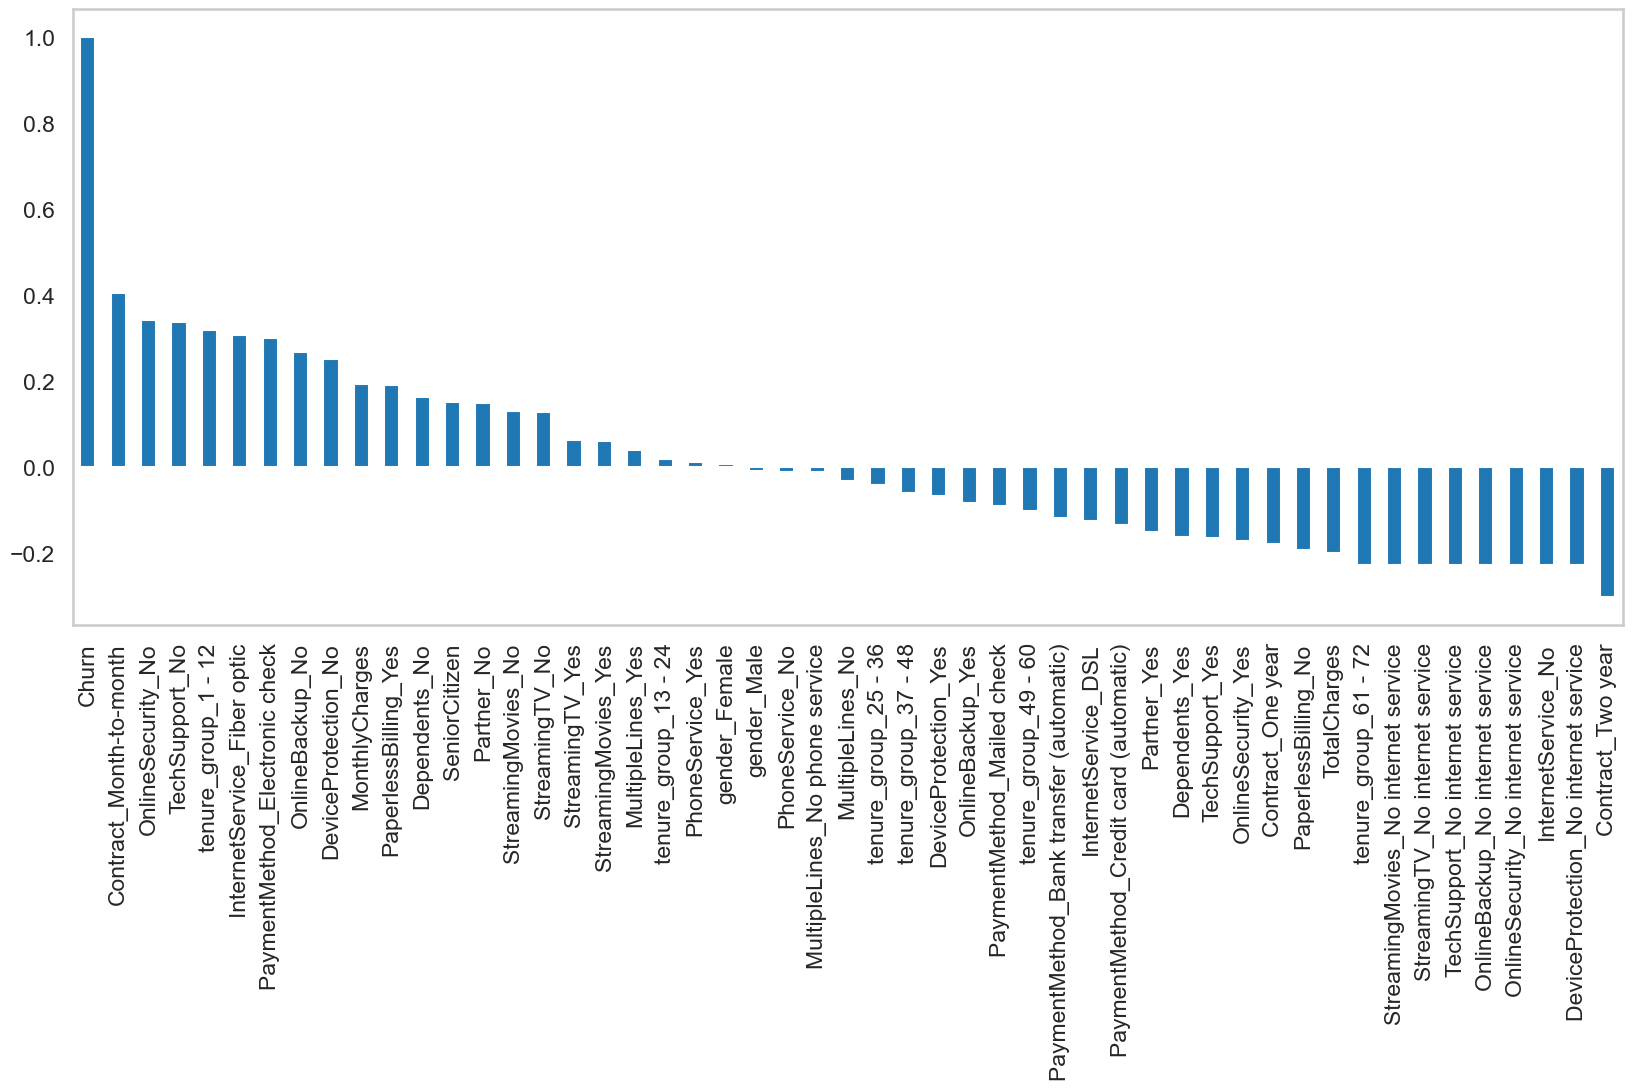

In [140]:
plt.figure(figsize=(20,8))
telco_data_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar',grid=False)

<Axes: >

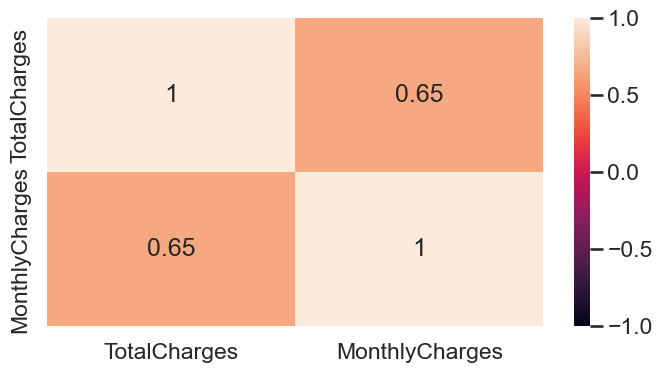

In [136]:
plt.figure(figsize=(8,4))
sns.heatmap(telco_data[['TotalCharges','MonthlyCharges']].corr(),annot=True,vmin=-1,vmax=1)

<Axes: >

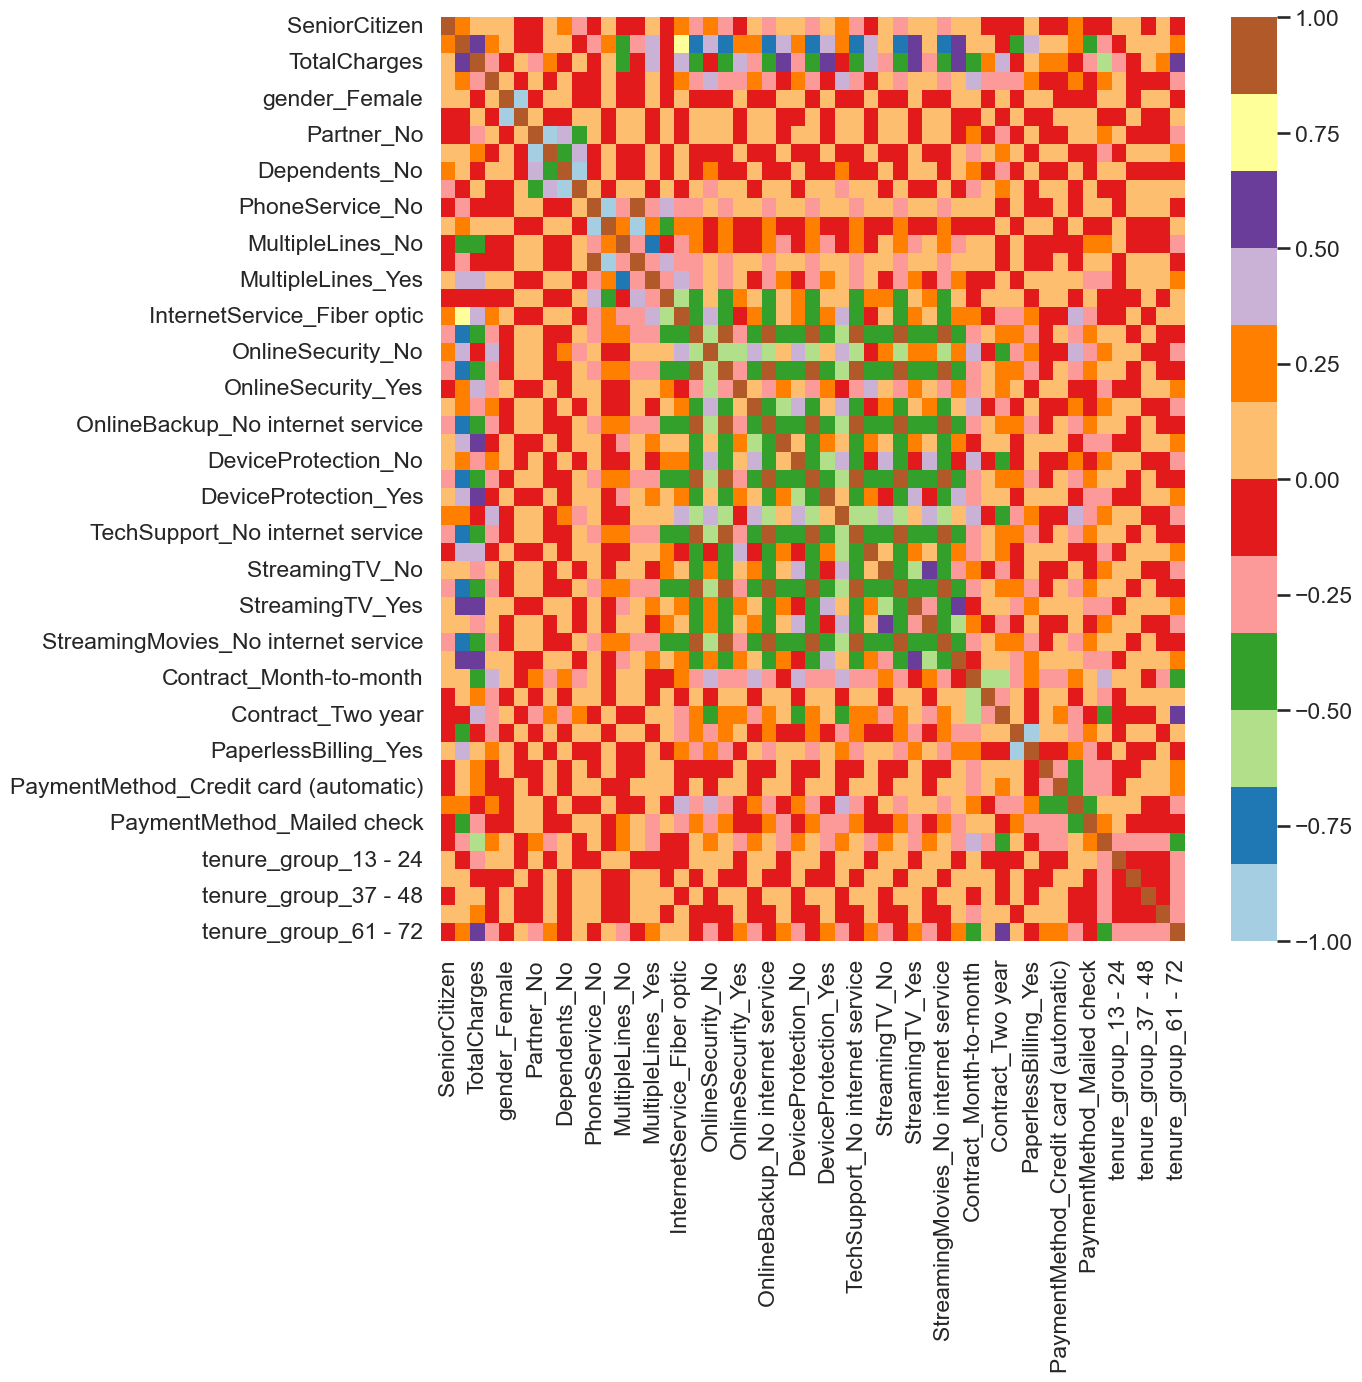

In [137]:
plt.figure(figsize=(12,12))
sns.heatmap(telco_data_dummies.corr(),cmap='Paired')

*Derived Insight*

**High Churn** seen in case of **Month to Month Contracts**, **No online security**, **No Tech Support**, **First year of subscription** and **Fibre Optics Internet**.

**Low Churn** is seen in case of **Long term contracts**, **Subscription without internet service** and the **customer engaged for 5+ years**.

Factors like **Gender**, **Availability of PhoneService** and **# of multiple lines** have almost **No impact** on churn.

This is also evident from the heatmap above.

##### Saving the cleaned dataset

In [146]:
telco_data_dummies.to_csv('telco_data.csv')